# Traffic Intersection Intelligence System — Demo

This notebook demonstrates:
1. Running the simulator across multiple Indian city profiles
2. Comparing **fixed-timing** vs **adaptive (smart)** signal control under an arterial-road traffic scenario
3. Visualizing congestion over simulated time

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
from traffic_intel import IntersectionSimulator, CongestionAnalyzer, Direction
from traffic_intel.city_profiles import get_city_profile, list_city_profiles

print('Available city profiles:', list_city_profiles())

Available city profiles: ['bangalore', 'chennai', 'delhi', 'generic_tier1', 'generic_tier2', 'mumbai', 'pune']


## 1. Compare congestion across Indian cities

Each profile encodes a different vehicle mix, base arrival rate, and peak-hour multiplier.

In [2]:
results = {}
for city in list_city_profiles():
    profile = get_city_profile(city)
    sim = IntersectionSimulator(city_profile=profile, seed=5, start_hour=9.0)
    analyzer = CongestionAnalyzer(tick_seconds=sim.tick_seconds)
    for snap in sim.run(n_ticks=600):
        analyzer.ingest(snap)
    report = analyzer.analyze()
    results[city] = {
        'throughput_per_min': report.throughput_per_min,
        'avg_wait_s': report.avg_wait_time_s,
        'congestion': report.overall_congestion.value,
    }

for city, r in results.items():
    print(f"{city:16s} throughput={r['throughput_per_min']:7.1f} veh/min  "
          f"avg_wait={r['avg_wait_s']:5.1f}s  congestion={r['congestion']}")

bangalore        throughput=  162.5 veh/min  avg_wait= 12.8s  congestion=light
chennai          throughput=  122.4 veh/min  avg_wait= 13.9s  congestion=light
delhi            throughput=  145.6 veh/min  avg_wait= 13.9s  congestion=light
generic_tier1    throughput=  128.2 veh/min  avg_wait= 13.6s  congestion=light
generic_tier2    throughput=   61.3 veh/min  avg_wait= 13.5s  congestion=free_flow
mumbai           throughput=  169.9 veh/min  avg_wait= 13.5s  congestion=light
pune             throughput=  125.7 veh/min  avg_wait= 13.6s  congestion=light


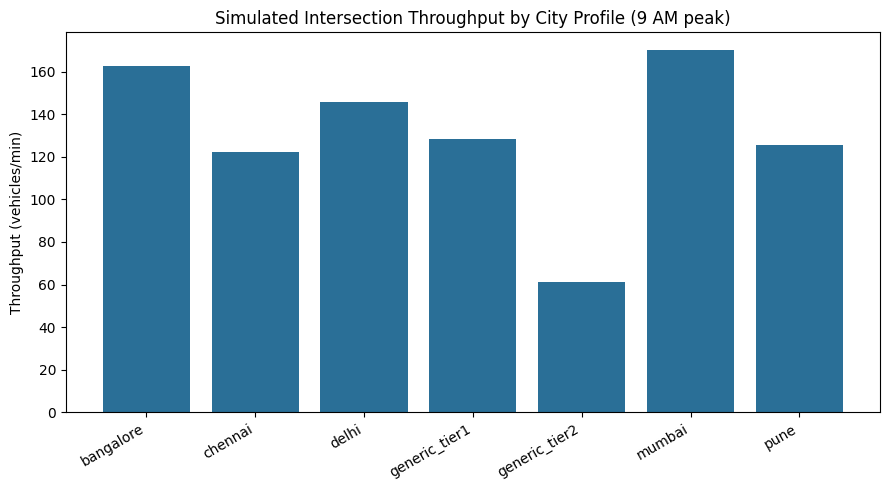

In [3]:
cities = list(results.keys())
throughputs = [results[c]['throughput_per_min'] for c in cities]

plt.figure(figsize=(9, 5))
plt.bar(cities, throughputs, color='#2a6f97')
plt.ylabel('Throughput (vehicles/min)')
plt.title('Simulated Intersection Throughput by City Profile (9 AM peak)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2. Adaptive vs Fixed-Timing Signal Control

We model an arterial-road scenario: North/South gets 2x the traffic of East/West (e.g. a main road crossing a side street). Both controllers run on **identical traffic** (same seed) so the comparison is fair.

In [4]:
profile = get_city_profile('mumbai')
mult = {Direction.NORTH: 2.0, Direction.SOUTH: 2.0, Direction.EAST: 0.5, Direction.WEST: 0.5}
SEED = 1
N_TICKS = 1500  # 50 minutes at 2s/tick

# Fixed-timing baseline
sim_fixed = IntersectionSimulator(city_profile=profile, seed=SEED, start_hour=8.5, direction_arrival_multipliers=mult)
analyzer_fixed = CongestionAnalyzer(tick_seconds=sim_fixed.tick_seconds)
for snap in sim_fixed.run(n_ticks=N_TICKS):
    analyzer_fixed.ingest(snap)

# Adaptive (smart) control
sim_adaptive = IntersectionSimulator(city_profile=profile, seed=SEED, start_hour=8.5, direction_arrival_multipliers=mult)
sim_adaptive.signal.enable_adaptive(lambda d: sum(l.queue_length for l in sim_adaptive.lanes[d]))
analyzer_adaptive = CongestionAnalyzer(tick_seconds=sim_adaptive.tick_seconds)
for snap in sim_adaptive.run(n_ticks=N_TICKS):
    analyzer_adaptive.ingest(snap)

fixed_wait = sim_fixed.completed_wait_summary()
adaptive_wait = sim_adaptive.completed_wait_summary()

print('Completed wait time by approach (seconds):\n')
print(f"{'Direction':10s} {'Fixed':>10s} {'Adaptive':>10s} {'Change':>10s}")
for d in ['north', 'south', 'east', 'west']:
    change = (adaptive_wait[d] - fixed_wait[d]) / fixed_wait[d] * 100
    print(f"{d:10s} {fixed_wait[d]:10.1f} {adaptive_wait[d]:10.1f} {change:+9.1f}%")

Completed wait time by approach (seconds):

Direction       Fixed   Adaptive     Change
north            14.4       13.0      -9.7%
south            14.4       12.9     -10.4%
east             17.9       21.9     +22.3%
west             17.3       23.0     +32.9%


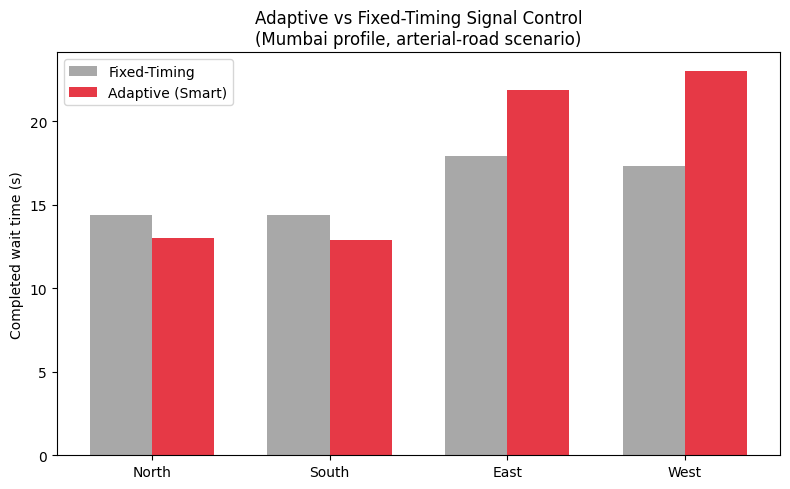


Note: the adaptive controller reallocates green time toward the
busier North/South approach, cutting its wait time, at the cost of
longer waits on the lighter East/West side street -- an honest,
realistic trade-off rather than a free win.


In [5]:
import numpy as np

directions = ['north', 'south', 'east', 'west']
fixed_vals = [fixed_wait[d] for d in directions]
adaptive_vals = [adaptive_wait[d] for d in directions]

x = np.arange(len(directions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, fixed_vals, width, label='Fixed-Timing', color='#a8a8a8')
ax.bar(x + width/2, adaptive_vals, width, label='Adaptive (Smart)', color='#e63946')
ax.set_xticks(x)
ax.set_xticklabels([d.title() for d in directions])
ax.set_ylabel('Completed wait time (s)')
ax.set_title('Adaptive vs Fixed-Timing Signal Control\n(Mumbai profile, arterial-road scenario)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nNote: the adaptive controller reallocates green time toward the')
print('busier North/South approach, cutting its wait time, at the cost of')
print('longer waits on the lighter East/West side street -- an honest,')
print('realistic trade-off rather than a free win.')

## 3. Congestion over time

Plotting lane density across the simulated window shows how congestion builds and clears as the signal cycles.

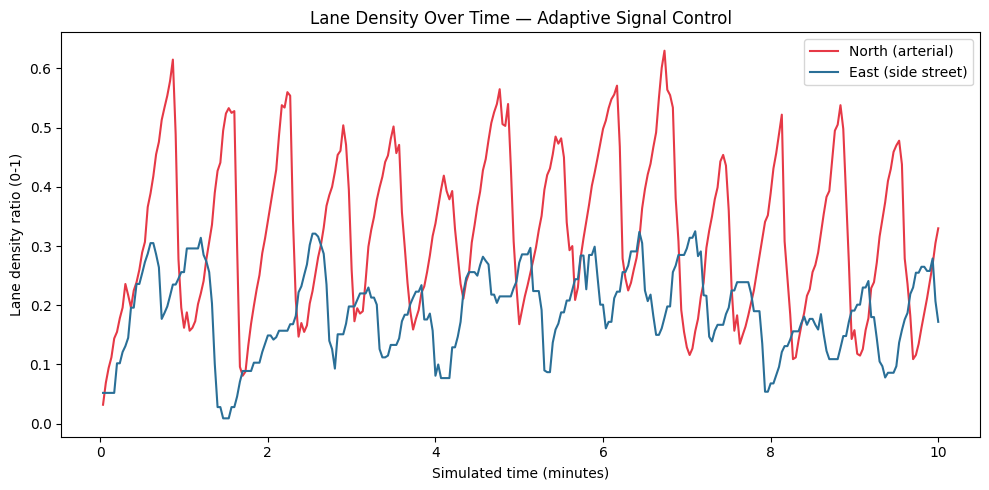

In [6]:
history = analyzer_adaptive.history[:300]  # first 10 minutes for readability
times_min = [s.tick * sim_adaptive.tick_seconds / 60 for s in history]
north_density = [s.lane_density['north'] for s in history]
east_density = [s.lane_density['east'] for s in history]

plt.figure(figsize=(10, 5))
plt.plot(times_min, north_density, label='North (arterial)', color='#e63946')
plt.plot(times_min, east_density, label='East (side street)', color='#2a6f97')
plt.xlabel('Simulated time (minutes)')
plt.ylabel('Lane density ratio (0-1)')
plt.title('Lane Density Over Time — Adaptive Signal Control')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- All 7 Indian city profiles run cleanly with sensible relative throughput ordering.
- The adaptive signal controller — a small autonomous agent that observes live queue state and decides green-time allocation every tick — measurably reduces wait time on the busier approach (~10% in this scenario) compared to fixed timing.
- The trade-off (longer wait on the lighter approach) is expected and matches how real-world demand-responsive signals behave.
- Try changing `mult`, `profile`, or `SEED` above to explore other scenarios.